In [28]:
import pprint
import matplotlib.pyplot as plt
import numpy as np
import csv
import json
import os

In [30]:
DATA_PATH = '/archive/Downloads/data (1).json'
DATA_DIR = '/archive/Downloads/datafiles/'

In [31]:
def get_metric(filepath, max_date):
    with open(filepath, 'r') as f:
        data = json.load(f)

    clusters = {}

    for row in data:
        if row['cluster'] not in clusters:
            clusters[row['cluster']] = []
        clusters[row['cluster']].append(row["date"])

    nRedep = 0
    nNew = 0

    for cluster in clusters:
        if all(date == max_date for date in clusters[cluster]):
            nNew += clusters[cluster].count(max_date)
        elif any(date == max_date for date in clusters[cluster]):
            nRedep += clusters[cluster].count(max_date)
    
    return nRedep, nNew

In [33]:
metrics = []
dates = []

for file in sorted(os.listdir(DATA_DIR)):
    print(file)
    if file.endswith('.json'):
        max_date = file.split('.')[0]
        nRedep, nNew = get_metric(os.path.join(DATA_DIR, file), max_date)
        metrics.append((max_date, nRedep, nNew))
        dates.append(max_date)

2024-09-26.json
2024-09-27.json
2024-09-28.json
2024-09-29.json
2024-09-30.json
2024-10-01.json
2024-10-02.json
2024-10-03.json
2024-10-04.json
2024-10-05.json
2024-10-06.json
2024-10-07.json
2024-10-08.json


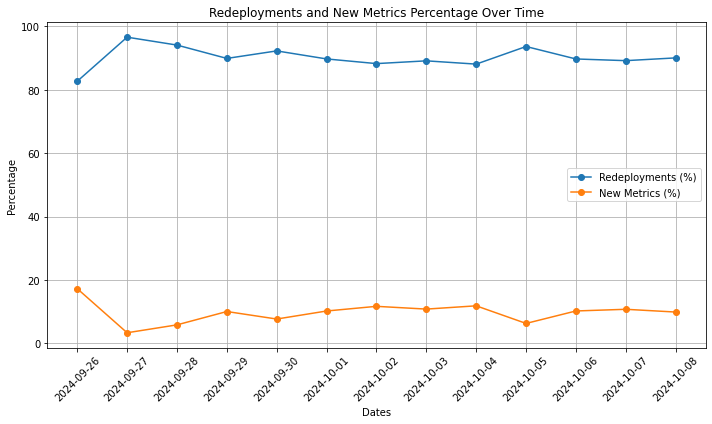

In [ ]:
# Extract the metrics data
dates = [metric[0] for metric in metrics]
nRedep = [metric[1] for metric in metrics]
nNew = [metric[2] for metric in metrics]

# Calculate the total metrics for each date
total_metrics = [redeploy + new for redeploy, new in zip(nRedep, nNew)]

# Calculate the percentage of redeployments and new metrics
nRedep_percentage = [(redeploy / total) * 100 if total != 0 else 0 for redeploy, total in zip(nRedep, total_metrics)]
nNew_percentage = [(new / total) * 100 if total != 0 else 0 for new, total in zip(nNew, total_metrics)]

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(dates, nRedep_percentage, label='Redeployments (%)', marker='o')
plt.plot(dates, nNew_percentage, label='New Deployments (%)', marker='o')

# Add labels and title
plt.xlabel('Dates')
plt.ylabel('Percentage')
plt.title('Redeployments and New Deployments Percentage Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()